<a href="https://colab.research.google.com/github/iHoshiii/GCIWorlds2026-competition/blob/improvements/upgraded_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [17]:

# 1. Setup & Environment
# Uses only the provided train.csv/test.csv files. No external data is used.

try:
    import lightgbm as lgb
    import xgboost as xgb
    from catboost import CatBoostClassifier
except ImportError:
    print("Installing missing libraries (LightGBM, XGBoost, CatBoost)...")
    !pip install -q lightgbm xgboost catboost
    import lightgbm as lgb
    import xgboost as xgb
    from catboost import CatBoostClassifier

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')

SEED = 42
N_SPLITS = 5

np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


## 2. Load the Data

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/00_GCIGlobal/competition"


/content/drive/MyDrive/00_GCIGlobal/competition


In [20]:
train = pd.read_csv('input/train.csv', index_col='Id')
test  = pd.read_csv('input/test.csv',  index_col='Id')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (2781, 15)
Test shape:  (696, 14)


,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
Id,,,,,,,,,,,,,,,
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


## 3. Data Analysis & EDA

### 3.1 Target Distribution

First, let's check how balanced the target is.

Draft rate: 0.648


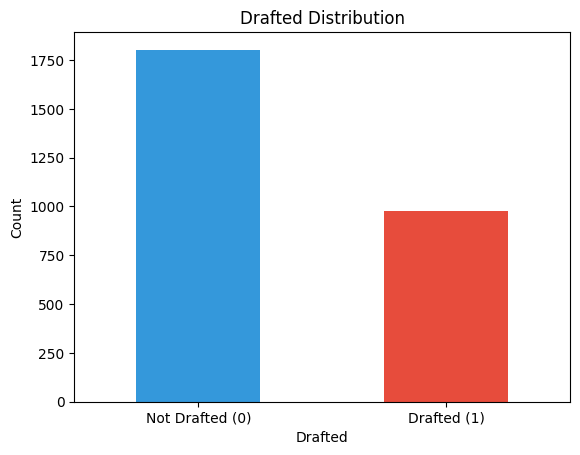

In [21]:
print('Draft rate:', train['Drafted'].mean().round(3))
train['Drafted'].value_counts().plot(kind='bar', title='Drafted Distribution', color=['#3498db', '#e74c3c'])
plt.xticks([0, 1], ['Not Drafted (0)', 'Drafted (1)'], rotation=0)
plt.ylabel('Count')
plt.show()

### 3.2 Missing Values

Many physical test columns have missing values. Let's see how many.

In [22]:
missing = train.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

Agility_3cone       0.348795
Shuttle             0.327940
Bench_Press_Reps    0.259259
Broad_Jump          0.208918
Vertical_Jump       0.199209
Age                 0.156419
Sprint_40yd         0.052140
dtype: float64


### 3.3 Draft Rate by Position Type

Some positions are drafted at much higher rates than others.

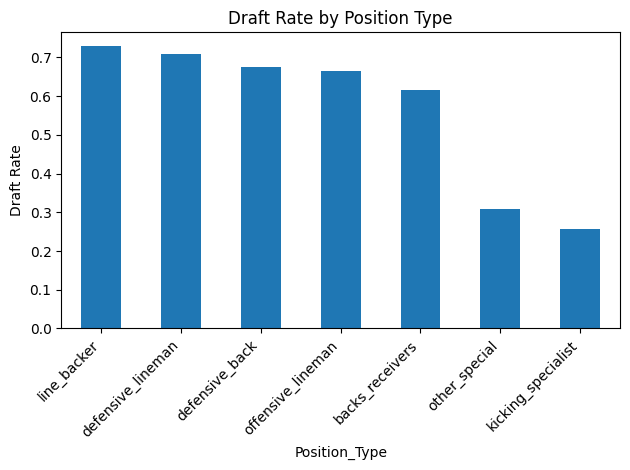

In [23]:
draft_by_pos = train.groupby('Position_Type')['Drafted'].mean().sort_values(ascending=False)
draft_by_pos.plot(kind='bar', title='Draft Rate by Position Type')
plt.ylabel('Draft Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Physical Test vs Draft

Drafted players tend to run faster (lower 40-yard dash time).

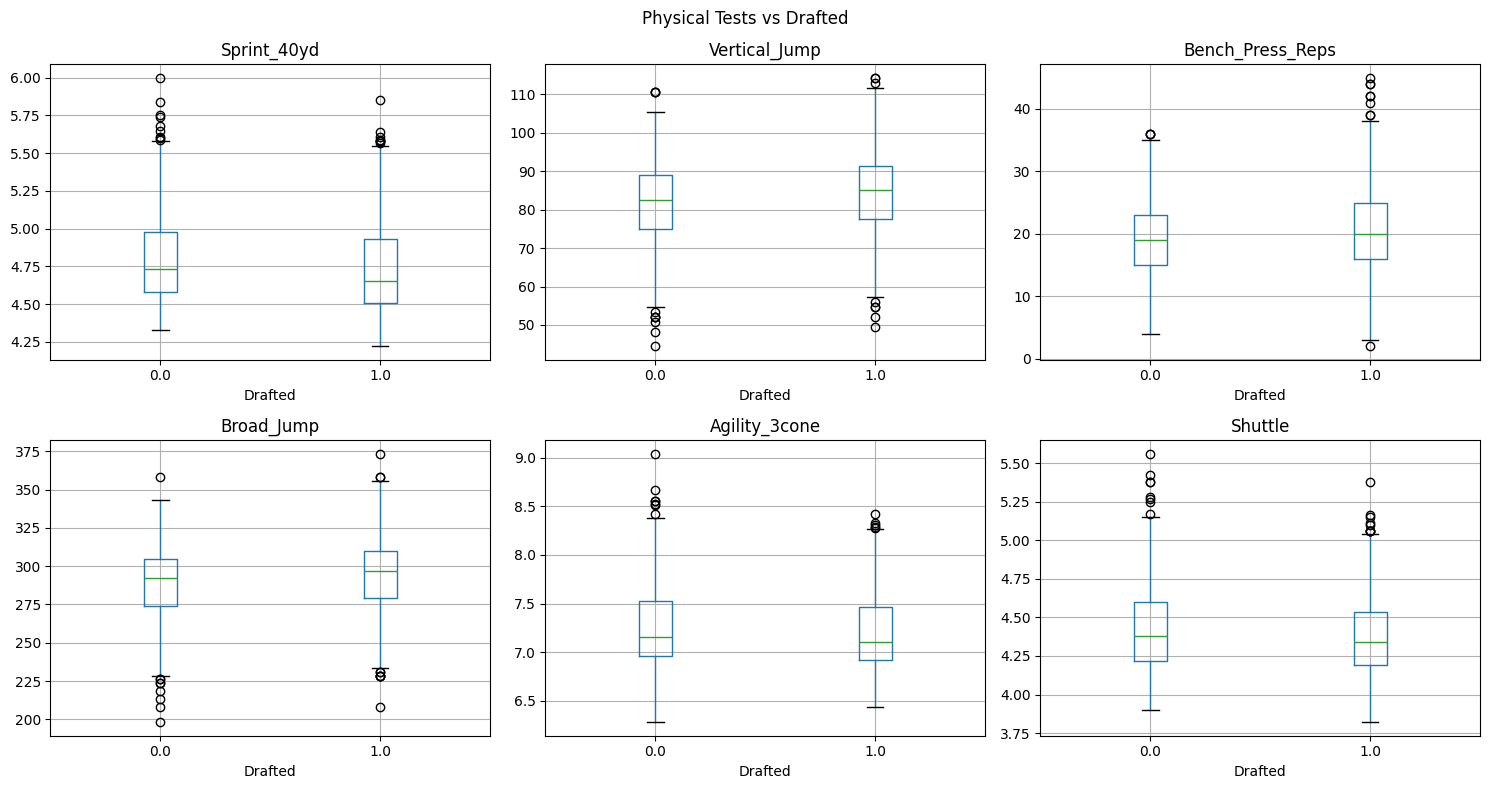

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
            'Broad_Jump', 'Agility_3cone', 'Shuttle']

for ax, col in zip(axes.flatten(), num_cols):
    train.boxplot(column=col, by='Drafted', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Drafted')

plt.suptitle('Physical Tests vs Drafted')
plt.tight_layout()
plt.show()

### 3.5 School Draft Rate

The School column has 236 unique values, but it carries useful signal — players from top programs get drafted more often. Instead of dropping it (as the baseline does), we will use **target encoding** to capture this signal.

In [25]:
school_rate = (
    train.groupby('School')['Drafted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Draft_Rate', 'count': 'N'})
    .query('N >= 10')
    .sort_values('Draft_Rate', ascending=False)
)
print('Top 10 schools by draft rate:')
print(school_rate.head(10))
print('\nBottom 10 schools by draft rate:')
print(school_rate.tail(10))

Top 10 schools by draft rate:
                    Draft_Rate   N
School                            
Northwestern          0.846154  13
Louisiana Tech        0.800000  10
North Carolina St.    0.800000  25
Georgia Tech          0.800000  15
UCLA                  0.780488  41
Georgia               0.777778  54
Oklahoma              0.777778  54
Texas Tech            0.769231  13
Rutgers               0.750000  16
Oregon St.            0.750000  12

Bottom 10 schools by draft rate:
              Draft_Rate   N
School                      
Michigan St.    0.500000  38
Houston         0.500000  12
Kansas St.      0.473684  19
Syracuse        0.470588  17
San Jose St.    0.466667  15
Colorado St.    0.461538  13
Toledo          0.454545  11
Indiana         0.450000  20
Duke            0.384615  13
BYU             0.357143  14


## 4. Preprocessing

Separate the target and define the columns used by the reproducible feature pipeline.


In [26]:

target = train['Drafted'].astype(int).copy()
train = train.drop(columns=['Drafted']).copy()

combine_cols = [
    'Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
    'Broad_Jump', 'Agility_3cone', 'Shuttle'
]
cat_cols = ['School', 'Position', 'Position_Type', 'Player_Type', 'School_Position']

print('Target shape:', target.shape)
print('Train shape: ', train.shape)


Target shape: (2781,)
Train shape:  (2781, 14)


### 4.1 Feature Engineering

These features use only `train.csv` and `test.csv`: missingness indicators, position-level imputation, size/speed ratios, position-relative z-scores, categorical frequencies, and school-position interactions.


In [27]:
# Safety definitions: keep this cell runnable even if the previous setup cell was skipped.
combine_cols = [
    'Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
    'Broad_Jump', 'Agility_3cone', 'Shuttle'
]
cat_cols = ['School', 'Position', 'Position_Type', 'Player_Type', 'School_Position']

def ensure_derived_columns(df):
    df = df.copy()
    df['School_Position'] = df['School'].astype(str) + '_' + df['Position'].astype(str)
    return df


def add_features(df, reference_df=None):
    df = ensure_derived_columns(df)
    ref = ensure_derived_columns(df if reference_df is None else reference_df)

    # Missingness itself is useful signal, so record it before imputation.
    for col in combine_cols:
        df[f'{col}_missing'] = df[col].isna().astype(int)
    df['Missing_Count'] = df[combine_cols].isna().sum(axis=1)

    # Impute combine measurements by Position, falling back to global train medians.
    pos_medians = ref.groupby('Position')[combine_cols].median()
    global_medians = ref[combine_cols].median()
    for col in combine_cols:
        df[col] = df[col].fillna(df['Position'].map(pos_medians[col])).fillna(global_medians[col])
        ref[col] = ref[col].fillna(ref['Position'].map(pos_medians[col])).fillna(global_medians[col])

    for frame in (df, ref):
        frame['BMI'] = frame['Weight'] / (frame['Height'] ** 2)
        weight_lbs = frame['Weight'] * 2.20462
        frame['Speed_Score'] = (weight_lbs * 200) / (frame['Sprint_40yd'] ** 4)
        frame['Weight_Adj_Forty'] = frame['Sprint_40yd'] / (frame['Weight'] ** (1 / 3))
        frame['Weight_X_Speed'] = frame['Weight'] / frame['Sprint_40yd']
        frame['Power_Density'] = frame['Bench_Press_Reps'] * frame['Weight'] / frame['Height']
        frame['Explosiveness'] = frame['Vertical_Jump'] + frame['Broad_Jump']
        frame['Agility_Index'] = frame['Agility_3cone'] + frame['Shuttle']
        frame['Size_Speed_Index'] = frame['BMI'] / frame['Sprint_40yd']

    for col in cat_cols:
        freq = ref[col].astype(str).value_counts(normalize=True)
        df[f'{col}_freq'] = df[col].astype(str).map(freq).fillna(0)

    zscore_cols = [
        'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump',
        'Agility_3cone', 'Shuttle', 'Speed_Score', 'BMI'
    ]
    for col in zscore_cols:
        stats = ref.groupby('Position')[col].agg(['mean', 'std'])
        pos_mean = df['Position'].map(stats['mean'])
        pos_std = df['Position'].map(stats['std']).fillna(0)
        df[f'{col}_pos_z'] = (df[col] - pos_mean) / (pos_std + 1e-6)

    df['Age_x_Position_freq'] = df['Age'] * df['Position_freq']
    return df.replace([np.inf, -np.inf], np.nan)


train_fe = add_features(train)
test_fe = add_features(test, reference_df=train)

print('Feature-engineered train:', train_fe.shape)
print('Feature-engineered test: ', test_fe.shape)


Feature-engineered train: (2781, 45)
Feature-engineered test:  (696, 45)


### 4.2 Leakage-Safe Target Encoding

School and position are strong signals. The training rows receive out-of-fold target encodings; the test rows use encodings learned from all training rows.


In [28]:

def add_oof_target_encoding(train_df, test_df, y, cols, n_splits=5, seed=42, smoothing=20):
    train_df = train_df.copy()
    test_df = test_df.copy()
    global_mean = y.mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cols:
        oof = np.full(len(train_df), global_mean, dtype=float)

        for tr_idx, val_idx in skf.split(train_df, y):
            fold_data = pd.DataFrame({
                col: train_df.iloc[tr_idx][col].astype(str),
                'target': y.iloc[tr_idx].values,
            })
            stats = fold_data.groupby(col)['target'].agg(['mean', 'count'])
            enc = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
            oof[val_idx] = train_df.iloc[val_idx][col].astype(str).map(enc).fillna(global_mean)

        full_data = pd.DataFrame({col: train_df[col].astype(str), 'target': y.values})
        stats = full_data.groupby(col)['target'].agg(['mean', 'count'])
        enc = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)

        train_df[f'{col}_TE'] = oof
        test_df[f'{col}_TE'] = test_df[col].astype(str).map(enc).fillna(global_mean)

    return train_df, test_df


train_fe, test_fe = add_oof_target_encoding(
    train_fe, test_fe, target, cat_cols,
    n_splits=N_SPLITS, seed=SEED, smoothing=20
)

for col in cat_cols:
    train_fe[col] = train_fe[col].astype(str)
    test_fe[col] = test_fe[col].astype(str)

numeric_cols = [c for c in train_fe.columns if c not in cat_cols and train_fe[c].dtype != 'object']
all_feature_cols = numeric_cols + cat_cols

print('Numeric features:', len(numeric_cols))
print('Categorical features:', cat_cols)


Numeric features: 45
Categorical features: ['School', 'Position', 'Position_Type', 'Player_Type', 'School_Position']


## 5. Model Training

Train a diverse ensemble: LightGBM, XGBoost, Extra Trees, Random Forest, HistGradientBoosting, and CatBoost. CatBoost receives the raw categorical columns directly.


In [ ]:

one_hot_preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=3, sparse_output=False), cat_cols),
])

models = {
    'lgb': lgb.LGBMClassifier(
        n_estimators=900, learning_rate=0.018, num_leaves=31,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=3,
        random_state=SEED, verbose=-1, n_jobs=1,
    ),
    'xgb': xgb.XGBClassifier(
        n_estimators=700, learning_rate=0.025, max_depth=4,
        min_child_weight=4, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=4, eval_metric='auc', random_state=SEED, n_jobs=1,
    ),
    'et': Pipeline([
        ('prep', one_hot_preprocess),
        ('model', ExtraTreesClassifier(
            n_estimators=500, min_samples_leaf=3, max_features='sqrt',
            random_state=SEED, n_jobs=1,
        )),
    ]),
    'rf': Pipeline([
        ('prep', one_hot_preprocess),
        ('model', RandomForestClassifier(
            n_estimators=450, min_samples_leaf=4, max_features='sqrt',
            random_state=SEED, n_jobs=1,
        )),
    ]),
    'hgb': Pipeline([
        ('prep', one_hot_preprocess),
        ('model', HistGradientBoostingClassifier(
            max_iter=350, learning_rate=0.03, l2_regularization=0.2,
            random_state=SEED,
        )),
    ]),
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
model_names = list(models.keys()) + ['cat']
oof_preds = {name: np.zeros(len(train_fe)) for name in model_names}
test_preds = {name: np.zeros(len(test_fe)) for name in model_names}

for fold, (tr_idx, val_idx) in enumerate(skf.split(train_fe, target), start=1):
    print(f'Fold {fold}/{N_SPLITS}')

    for name, base_model in models.items():
        model = clone(base_model)
        cols = numeric_cols if name in ['lgb', 'xgb'] else all_feature_cols

        model.fit(train_fe.iloc[tr_idx][cols], target.iloc[tr_idx])
        oof_preds[name][val_idx] = model.predict_proba(train_fe.iloc[val_idx][cols])[:, 1]
        test_preds[name] += model.predict_proba(test_fe[cols])[:, 1] / N_SPLITS

    cat_model = CatBoostClassifier(
        iterations=900, learning_rate=0.025, depth=5, l2_leaf_reg=8,
        loss_function='Logloss', eval_metric='AUC', random_seed=SEED,
        verbose=0, allow_writing_files=False,
    )
    cat_model.fit(
        train_fe.iloc[tr_idx][all_feature_cols], target.iloc[tr_idx],
        cat_features=cat_cols,
        eval_set=(train_fe.iloc[val_idx][all_feature_cols], target.iloc[val_idx]),
        early_stopping_rounds=100,
    )
    oof_preds['cat'][val_idx] = cat_model.predict_proba(train_fe.iloc[val_idx][all_feature_cols])[:, 1]
    test_preds['cat'] += cat_model.predict_proba(test_fe[all_feature_cols])[:, 1] / N_SPLITS

print('\nOOF AUC by model:')
for name in model_names:
    print(f'{name:>4}: {roc_auc_score(target, oof_preds[name]):.5f}')


Fold 1/5
Fold 2/5
Fold 3/5


## 6. Stacking and Final Blend

Use out-of-fold predictions to train a regularized logistic meta-model. The final prediction is a conservative blend of the strongest single model and the stacked model.


In [ ]:

stack_train = np.column_stack([oof_preds[name] for name in model_names])
stack_test = np.column_stack([test_preds[name] for name in model_names])

meta_oof = np.zeros(len(target))
meta_test = np.zeros(len(test_fe))

for tr_idx, val_idx in skf.split(stack_train, target):
    meta_model = LogisticRegression(C=0.5, solver='liblinear', random_state=SEED)
    meta_model.fit(stack_train[tr_idx], target.iloc[tr_idx])
    meta_oof[val_idx] = meta_model.predict_proba(stack_train[val_idx])[:, 1]
    meta_test += meta_model.predict_proba(stack_test)[:, 1] / N_SPLITS

cat_auc = roc_auc_score(target, oof_preds['cat'])
meta_auc = roc_auc_score(target, meta_oof)
print(f'CatBoost OOF AUC: {cat_auc:.5f}')
print(f'Stacked  OOF AUC: {meta_auc:.5f}')

# CatBoost was strongest in validation, but the stack adds a little diversity for the hidden test set.
test_pred_proba_mean = np.clip(0.75 * test_preds['cat'] + 0.25 * meta_test, 0.001, 0.999)
print('Final prediction range:', test_pred_proba_mean.min().round(5), test_pred_proba_mean.max().round(5))


## 7. Create the Submission File

Keep the required `sample_submission.csv` format exactly: `Id` plus predicted `Drafted` probabilities.


In [ ]:

PATH = Path('input')

# Basic format checks before saving.
assert len(test_pred_proba_mean) == len(pd.read_csv(PATH / 'sample_submission.csv'))
assert np.isfinite(test_pred_proba_mean).all()
assert ((test_pred_proba_mean >= 0) & (test_pred_proba_mean <= 1)).all()

print("Variable 'test_pred_proba_mean' is ready for the protected submission cell.")


In [ ]:

# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

print('submission.csv saved!')
print(submission.head())
print('Submission shape:', submission.shape)
